In [2]:
from abracalibra.forward_model import ForwardModel
from abracalibra.approximatebayesiancomputation import ApproximateBayesianComputation
from abracalibra.eki import EnsembleKalmanInversion
from abracalibra.history_matching import HistoryMatchingMultiTask
from abracalibra.summary import implausibility_univariate_distr
from torch.distributions import MultivariateNormal,Uniform


import torch
import matplotlib.pyplot as plt 

def sine_wave(x, a, b, c,d):
    return a * torch.sin(b * x + c)*torch.exp(-x/3)  + d

x = torch.linspace(0, 5, 10)
fixed_params = {'a': 1.0, 'c': 0.4,'d':0.3}
noise = 0.05

y = sine_wave(x, **fixed_params, b=0.78) + torch.randn_like(x)*noise

fwd = ForwardModel(sine_wave,vectorized=True, x=x, a=fixed_params['a'], c=fixed_params['c'], d=fixed_params['d'])

observables = MultivariateNormal(y, noise*noise*torch.eye(len(y)))

/Users/robcking/PhD/CalibBench/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
priors = {'b':Uniform(0,2)}
def summary(y,true_y):
    return torch.max(implausibility_univariate_distr(y,true_y),dim=-1).values 
hm = HistoryMatchingMultiTask(['b'],priors,observables,summary,ensemble_size=5,implausibility_cutoff=3,forward=fwd)
hm.calibrate(1)

Step 0 Loss: 1.1870592832565308
Step 1 Loss: 1.1576670408248901
Step 2 Loss: 1.1292227506637573
Step 3 Loss: 1.1016684770584106
Step 4 Loss: 1.07496976852417
Step 5 Loss: 1.0491149425506592
Step 6 Loss: 1.024111032485962
Step 7 Loss: 0.9999707937240601
Step 8 Loss: 0.9766849279403687
Step 9 Loss: 0.95420241355896
Step 10 Loss: 0.932424008846283
Step 11 Loss: 0.911210298538208
Step 12 Loss: 0.8904066681861877
Step 13 Loss: 0.8698641061782837
Step 14 Loss: 0.8494441509246826
Step 15 Loss: 0.8290199041366577
Step 16 Loss: 0.8084808588027954
Step 17 Loss: 0.7877342104911804
Step 18 Loss: 0.7667099833488464
Step 19 Loss: 0.7453646659851074
Step 20 Loss: 0.7236917614936829
Step 21 Loss: 0.7017282247543335
Step 22 Loss: 0.6795446872711182
Step 23 Loss: 0.6572207808494568
Step 24 Loss: 0.6348168253898621
Step 25 Loss: 0.6123582720756531
Step 26 Loss: 0.5898395776748657
Step 27 Loss: 0.5672454237937927
Step 28 Loss: 0.54457688331604
Step 29 Loss: 0.5218793749809265
Step 30 Loss: 0.4992718100547

<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
/var/folders/58/1mynp4bn1pg61mc1j6p3nnxc0000gp/T/ipykernel_44646/2443455306.py:17: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_xlabel("$\omega$")
/var/folders/58/1mynp4bn1pg61mc1j6p3nnxc0000gp/T/ipykernel_44646/2443455306.py:28: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_xlabel("$\omega$")


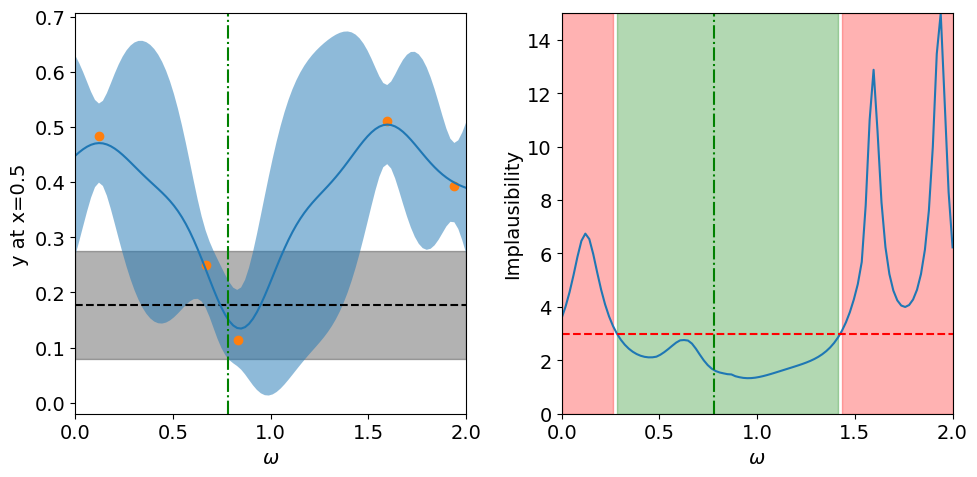

In [4]:
em = hm.emulators[hm.current_wave - 1]
em.eval()
plt.rcParams.update({'font.size': 14})
a = torch.linspace(0, 2, 100)
imp = hm.implausibility(a,wave=hm.current_wave - 1)
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
plot_dim = 8
with torch.no_grad():
    pred_val = em(a)
    lower,upper = pred_val.confidence_region()
    ax1.axhline(y=y[plot_dim],color='black',linestyle='--')
    ax1.fill_between(a,y[plot_dim] - 1.96*noise,y[plot_dim] + 1.96*noise,alpha=0.3,color='black')
    ax1.set_xlim(0,2)
    ax1.plot(a,pred_val.mean[:,plot_dim])
    ax1.fill_between(a,lower[:,plot_dim],upper[:,plot_dim],alpha=0.5)
    ax1.scatter(hm.params[:,:].view(-1,1),hm.results[:,:,plot_dim].view(-1,1))
    ax1.set_xlabel("$\omega$")
    ax1.axvline(0.78,color='green',linestyle='-.')
    ax1.set_ylabel("y at x=0.5")

    ax2.fill_between(a,torch.zeros_like(a),torch.ones_like(a)*imp.max(),alpha=0.3,color='green',where=imp<3)
    ax2.fill_between(a,torch.zeros_like(a),torch.ones_like(a)*imp.max(),alpha=0.3,color='red',where=imp>=3)
    ax2.plot(a,imp)
    ax2.set_xlim(0,2)
    ax2.set_ylim(0,imp.max())
    ax2.axvline(0.78,color='green',linestyle='-.')
    ax2.axhline(3,color='red',linestyle='--')
    ax2.set_xlabel("$\omega$")
    ax2.set_ylabel("Implausibility")

fig.tight_layout()
fig.savefig("history_matching.png",dpi=300)



In [ ]:
def harder_sine_wave(x,y,a,b,c,d,e):
    return a * torch.sin(b * x + c*y + d)  + e

x = torch.linspace(0, 5, 5)
y = torch.linspace(0,5, 5)
X,Y = torch.meshgrid(x,y,indexing='ij')

fixed_params = {
    'a': 1.0,
    'b': 0.78,
    'c': 0.4,
    'd': 0.3,
    'e': 0.5
}

noise = 0.05    
fwd = ForwardModel(harder_sine_wave,vectorized=True, x=X.ravel(), y=Y.ravel())
observables = MultivariateNormal(fwd(torch.tensor([fixed_params['a'],fixed_params['b'],fixed_params['c'],fixed_params['d'],fixed_params['e']])), noise*noise*torch.eye(X.numel()))
parameters = ['a','b','c','d','e']
priors = {'a':Uniform(0,2.0),'b':Uniform(0,1),'c':Uniform(0,1),'d':Uniform(0,1),'e':Uniform(0,1)}
def summary(y,true_y):
    return torch.max(implausibility_univariate_distr(y,true_y),dim=-1).values 
hm = HistoryMatchingMultiTask(parameters,priors,observables,summary,ensemble_size=20,implausibility_cutoff=3,forward=fwd)
hm.calibrate(5)

Step 0 Loss: 1.2761435508728027
Step 1 Loss: 1.253698468208313
Step 2 Loss: 1.2323696613311768
Step 3 Loss: 1.2120991945266724
Step 4 Loss: 1.1928021907806396
Step 5 Loss: 1.174405574798584
Step 6 Loss: 1.1568496227264404
Step 7 Loss: 1.14009690284729
Step 8 Loss: 1.1241345405578613
Step 9 Loss: 1.1089580059051514
Step 10 Loss: 1.0945607423782349
Step 11 Loss: 1.080939769744873
Step 12 Loss: 1.0680944919586182
Step 13 Loss: 1.0560170412063599
Step 14 Loss: 1.044696569442749
Step 15 Loss: 1.0341099500656128
Step 16 Loss: 1.024213433265686
Step 17 Loss: 1.014947772026062
Step 18 Loss: 1.0062531232833862
Step 19 Loss: 0.9980689883232117
Step 20 Loss: 0.9903321266174316
Step 21 Loss: 0.9829803705215454
Step 22 Loss: 0.9759491086006165
Step 23 Loss: 0.9691798686981201
Step 24 Loss: 0.9626253843307495
Step 25 Loss: 0.9562431573867798
Step 26 Loss: 0.9499948620796204
Step 27 Loss: 0.9438463449478149
Step 28 Loss: 0.9377690553665161
Step 29 Loss: 0.9317431449890137
Step 30 Loss: 0.925756871700

In [8]:
hm.nroy(torch.tensor([fixed_params['a'],fixed_params['b'],fixed_params['c'],fixed_params['d'],fixed_params['e']]),wave=hm.current_wave - 1)

tensor(True)

In [ ]:
import gpytorch


em = hm.emulators[hm.current_wave - 1]
em.eval()
a = torch.linspace(0, 2, 100)
b = torch.linspace(0, 1, 100)
c = torch.linspace(0, 1, 100)
A,B = torch.meshgrid(a,b,indexing='ij')
thetas = torch.stack([A,B],dim=-1).view(-1,2)
imp = hm.implausibility(thetas,wave=hm.current_wave - 1)
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
with torch.no_grad(),gpytorch.settings.fast_pred_var():
    pred_val = em(thetas).mean.view(100,100,hm.number_of_observables)
    ax1.contourf(B,A,pred_val[:,:,8])
    ax1.scatter([fixed_params['c']],[fixed_params['b']],color='black')
    ax2.pcolormesh(B,A,imp.view(100,100) < 3 )
    ax2.scatter([fixed_params['c']],[fixed_params['b']],color='black')

   

RuntimeError: shape '[10000]' is invalid for input of size 4000